# Task 0 — Data Exploratory Analysis (EDA) sul Dataset QEvasion

Questo notebook analizza il dataset utilizzato per il fine-tuning di Llama 3.1.
L'obiettivo è estrarre statistiche utili sulle distribuzioni delle etichette (Clarity ed Evasion), calcolare la lunghezza media dei testi e visualizzare la correlazione tra le tecniche di evasione e le macro-categorie di chiarezza.

## Environment Setup

This section configures the execution environment, detects whether the notebook is running locally or on Google Colab, sets the project paths, and prepares the output directory for dataset analysis results and visualizations.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
import sys
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path configuration and environment detection (Colab / Local)
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("Google Colab environment detected. Google Drive mounted successfully.")

    # Base path on Google Drive
    BASE_DIR = "/content/drive/MyDrive/progettoLLM"

except ImportError:
    print("Local environment detected.")

    # Local base path (set to the current project root)
    BASE_DIR = "."

REPO_DIR = os.path.join(BASE_DIR, "CLARITY")

# Path for saving plots and analysis results
ANALYSIS_DIR = os.path.join(REPO_DIR, "analisi_dataset")
os.makedirs(ANALYSIS_DIR, exist_ok=True)
print(f"Output directory set to: {ANALYSIS_DIR}")

PROJECT_ROOT = Path(REPO_DIR).resolve()   # notebooks/ is one level below the project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
Google Colab environment detected. Google Drive mounted successfully.
Output directory set to: /content/drive/MyDrive/progettoLLM/CLARITY/analisi_dataset


## Dataset Loading and Pandas Conversion

This section loads the dataset, splits it into training and test sets, converts both splits into Pandas DataFrames for statistical analysis, and merges them into a single DataFrame while preserving split information.

In [2]:
from src.data.dataset_loader import load_and_split_dataset

raw_ds = load_and_split_dataset(seed=42, verbose=True)

dataset_train = raw_ds['train']
dataset_test  = raw_ds['test']

# Conversion to Pandas DataFrames for statistical analysis
df_train = dataset_train.to_pandas()
df_test  = dataset_test.to_pandas()

# Add a column to identify the dataset split
df_train['split'] = 'Train'
df_test['split'] = 'Test'

# Merge into a single DataFrame
df_all = pd.concat([df_train, df_test], ignore_index=True)

print("Dataset loaded successfully.")
print(f" - Training examples: {len(df_train)}")
print(f" - Test examples:     {len(df_test)}")
print(f" - Total examples:    {len(df_all)}\n")

display(df_all.head(3))

README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

  train       :  2758 samples
  validation  :   690 samples
  test        :   308 samples
Dataset loaded successfully.
 - Training examples: 2758
 - Test examples:     308
 - Total examples:    3066



,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label,split
0,The President's News Conference With Prime Min...,"May 16, 2013",Barack Obama,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Thank you, Mr. President. I'd like to ask y...","Well, I'll let you guys engage in those compar...",The question consists of 4 parts:\n\n1. Do you...,Question part: 1. Do you believe that the seiz...,How do you feel about comparisons by some of y...,...,None,None,None,False,False,False,2198,Clear Non-Reply,Declining to answer,Train
1,The President's News Conference,"December 22, 2010",Barack Obama,https://www.presidency.ucsb.edu/documents/the-...,4,"Q. Yes, sir. Mr. President, can you explain th...","Look, the frustration that people felt about t...",The question consists of 2 parts:\n\n1. Anger ...,Question part: 1. Anger and outrage of Democra...,Is that a divide that you may be contributing ...,...,None,None,None,False,False,False,2505,Ambivalent,Implicit,Train
2,The President's News Conference With President...,"August 06, 2008",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,2,"Q. Thank you, both. To President Bush, China's...",I've been meeting with Chinese leaders now for...,The question consists of 2 parts:\n\n1. To Pre...,"Question part: 1. To President Bush - ""What do...",For people who think that this is just another...,...,None,None,None,False,False,False,2774,Ambivalent,General,Train


## Clarity Label Distribution Analysis

This section analyzes the distribution of the clarity labels (Task 1), comparing the training and test splits. It computes label frequencies and percentages, then visualizes the results with a bar plot.

--- Clarity Label Distribution (Task 1) ---
clarity_label
Ambivalent         1817
Clear Reply         938
Clear Non-Reply     311
Name: count, dtype: int64

Percentages:
clarity_label
Ambivalent         59.262883
Clear Reply        30.593607
Clear Non-Reply    10.143509
Name: proportion, dtype: float64


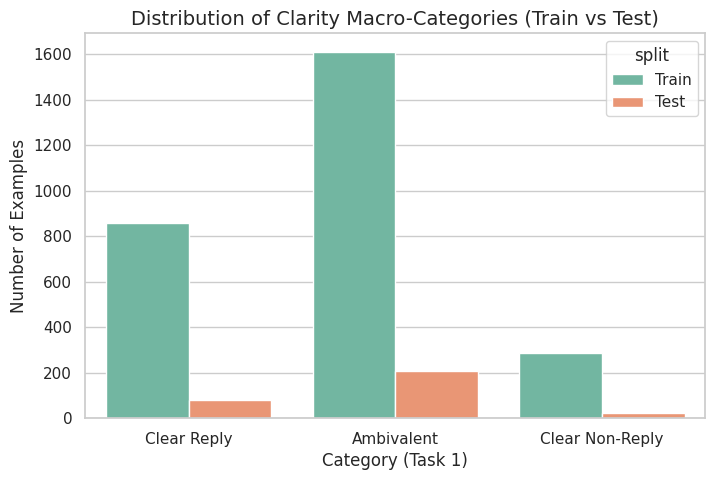

In [3]:
# ============================================================
# CELL 3 — Macro-Category Distribution (Task 1: Clarity)
# ============================================================

print("--- Clarity Label Distribution (Task 1) ---")
clarity_counts = df_all['clarity_label'].value_counts()
print(clarity_counts)
print(f"\nPercentages:\n{df_all['clarity_label'].value_counts(normalize=True) * 100}")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_all, x='clarity_label', hue='split', palette='Set2',
                   order=["Clear Reply", "Ambivalent", "Clear Non-Reply"])

plt.title('Distribution of Clarity Macro-Categories (Train vs Test)', fontsize=14)
plt.xlabel('Category (Task 1)', fontsize=12)
plt.ylabel('Number of Examples', fontsize=12)

# Save the plot
plt.savefig(f"{ANALYSIS_DIR}/clarity_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

## Evasion Technique Distribution Analysis

This section analyzes the distribution of evasion techniques (Task 2) across the dataset. It reports label frequencies and visualizes the differences between training and test splits.

--- Evasion Technique Distribution (Task 2) ---
evasion_label
Explicit               938
Dodging                607
Implicit               438
General                375
Deflection             327
Declining to answer    129
Claims ignorance       106
Clarification           76
Partial/half-answer     70
Name: count, dtype: int64


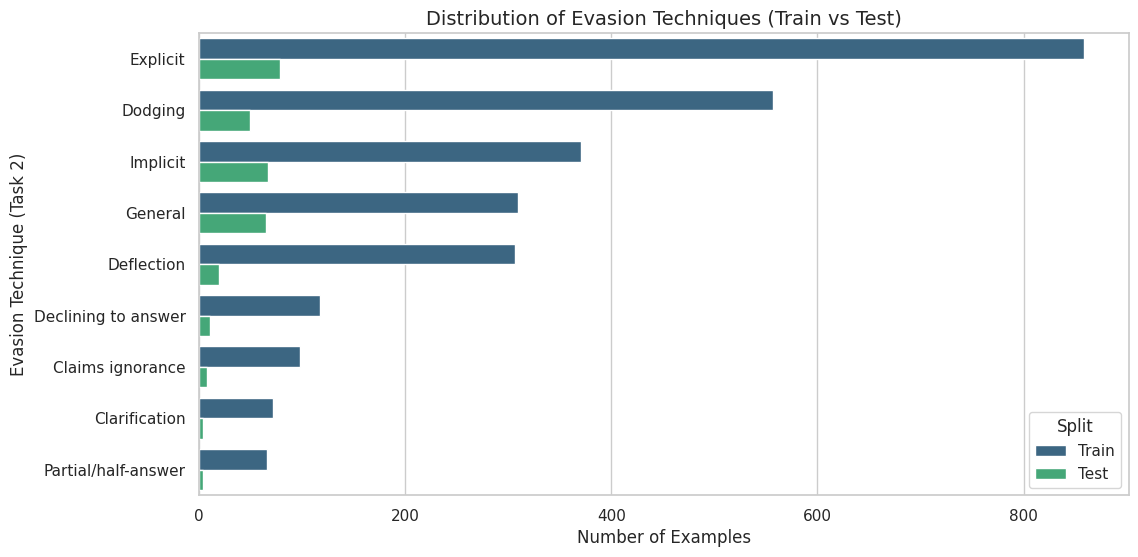

In [4]:
print("--- Evasion Technique Distribution (Task 2) ---")
evasion_counts = df_all['evasion_label'].value_counts()
print(evasion_counts)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_all, y='evasion_label', hue='split', palette='viridis',
                   order=evasion_counts.index)

plt.title('Distribution of Evasion Techniques (Train vs Test)', fontsize=14)
plt.xlabel('Number of Examples', fontsize=12)
plt.ylabel('Evasion Technique (Task 2)', fontsize=12)
plt.legend(title='Split', loc='lower right')

plt.savefig(f"{ANALYSIS_DIR}/evasion_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

## Text Length Analysis (Word Count)

This section analyzes the length of questions and answers by computing the number of words in each text. It provides descriptive statistics and visualizes the word count distributions.

--- Text Length Statistics (Number of Words) ---


,word_count_question,word_count_answer
count,3066.000000,3066.000000
mean,61.139596,293.088715
std,59.797315,297.040009
min,3.000000,1.000000
25%,23.000000,61.000000
50%,51.000000,209.500000
75%,81.000000,436.000000
max,780.000000,2117.000000


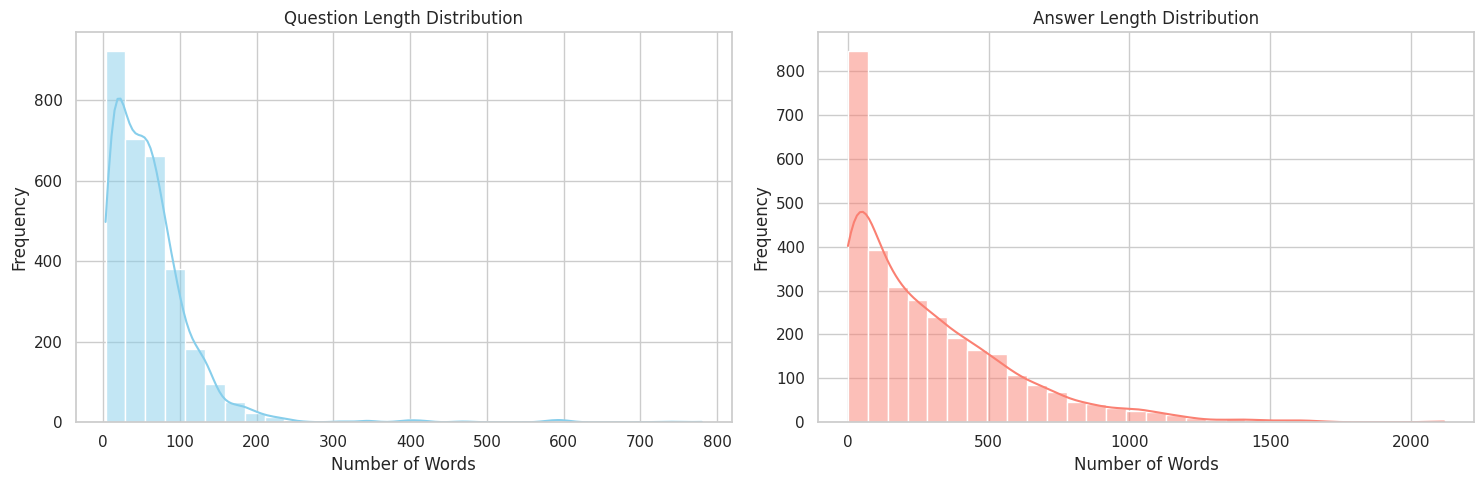

In [5]:
# Compute the number of words for each question and answer
df_all['word_count_question'] = df_all['interview_question'].apply(lambda x: len(str(x).split()))
df_all['word_count_answer']   = df_all['interview_answer'].apply(lambda x: len(str(x).split()))

print("--- Text Length Statistics (Number of Words) ---")
display(df_all[['word_count_question', 'word_count_answer']].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Question histogram
sns.histplot(df_all['word_count_question'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Question Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Answer histogram
sns.histplot(df_all['word_count_answer'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Answer Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f"{ANALYSIS_DIR}/text_length_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

## Correlation Analysis Between Tasks

This section analyzes the relationship between evasion techniques (Task 2) and clarity labels (Task 1) using a contingency table. The resulting heatmap shows how evasion categories map to clarity outcomes in the ground truth dataset.

--- Crosstab: Evasion Label vs Clarity Label ---


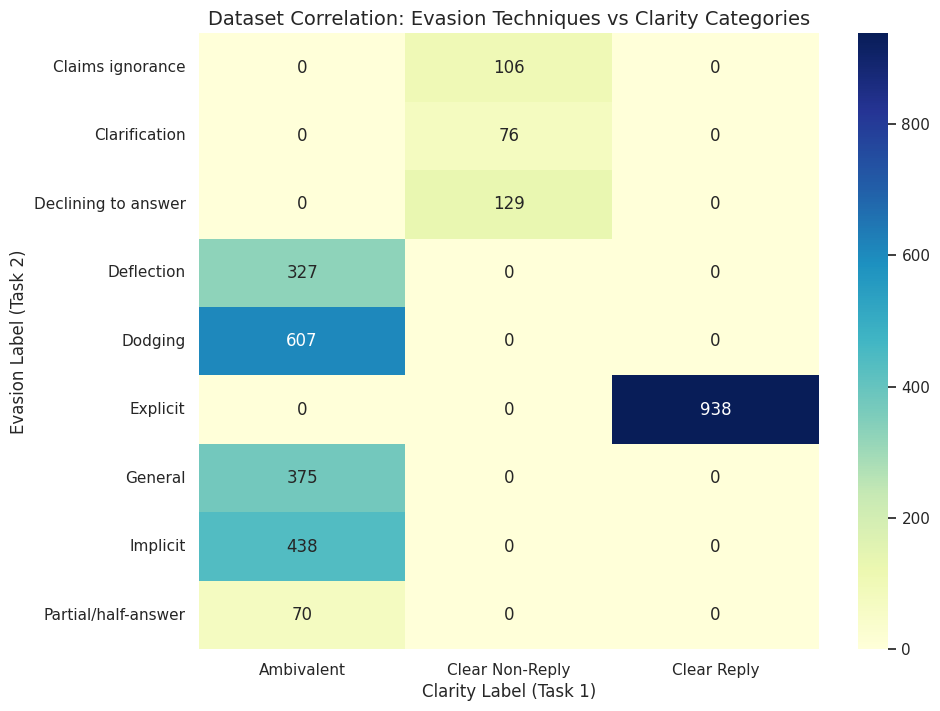

Analysis completed! Plots and data saved to: /content/drive/MyDrive/progettoLLM/CLARITY/analisi_dataset


In [6]:
print("--- Crosstab: Evasion Label vs Clarity Label ---")
crosstab_df = pd.crosstab(df_all['evasion_label'], df_all['clarity_label'])

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Dataset Correlation: Evasion Techniques vs Clarity Categories', fontsize=14)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Evasion Label (Task 2)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/correlation_heatmap_t1_t2.png", bbox_inches='tight', dpi=300)
plt.show()

# Save the dataset with the computed statistics
df_all.to_csv(f"{ANALYSIS_DIR}/dataset_statistics_complete.csv", index=False)
print(f"Analysis completed! Plots and data saved to: {ANALYSIS_DIR}")

## Zero-Shot Tone Classification

This section applies a zero-shot classification model to analyze the tone of interview answers. The model predicts one of the predefined tone categories and assigns the resulting labels to the dataset.

In [7]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Model initialization with FP16 (required for speed optimization on T4 GPUs)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0,
                      torch_dtype=torch.float16)

candidate_labels = ["Assertive", "Guarded", "Dismissive"]

# 2. Convert the column into a Hugging Face Dataset object
# Limit to 200 words to prevent GPU overload
print("Preparing data...")
temp_df = pd.DataFrame({
    "text": df_all['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:200]))
})
dataset = Dataset.from_pandas(temp_df)

# 3. Execution using Dataset + Pipeline + tqdm
results = []
batch_size = 16

print(f"Starting batch analysis of {len(dataset)} rows...")

for out in tqdm(classifier(KeyDataset(dataset, "text"),
                           candidate_labels=candidate_labels,
                           batch_size=batch_size,
                           truncation=True),
                total=len(dataset)):
    results.append(out['labels'][0])

# 4. Final assignment
df_all['tone'] = results
print("Analysis completed!")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Preparing data...
Starting batch analysis of 3066 rows...


  0%|          | 0/3066 [00:00<?, ?it/s]

Analysis completed!


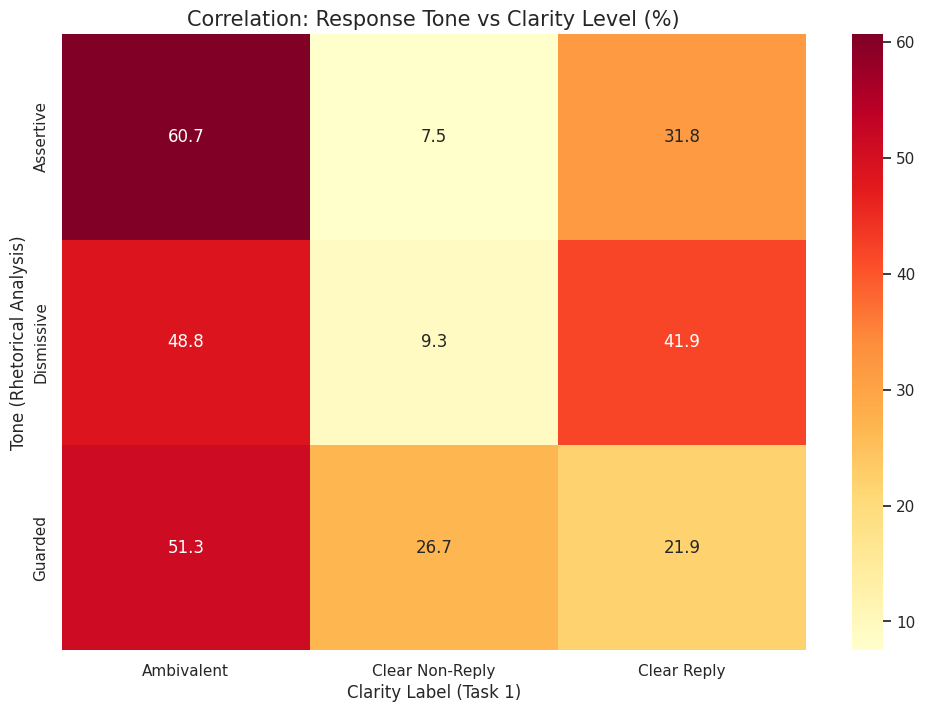

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the contingency table (Crosstab)
tone_clarity_crosstab = pd.crosstab(df_all['tone'], df_all['clarity_label'], normalize='index') * 100

# Display the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tone_clarity_crosstab, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Correlation: Response Tone vs Clarity Level (%)', fontsize=15)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Tone (Rhetorical Analysis)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/heatmap_tone_clarity_4.png", bbox_inches='tight')
plt.show()

## Answer Length Categorization

This section categorizes answers based on their length using quantile-based grouping. The dataset is divided into three groups with an equal number of samples: short, medium, and long answers.

In [9]:
import pandas as pd
import numpy as np

# Use pd.qcut to divide answers into 3 groups with the same number of samples (tertiles)
# labels=["Short", "Medium", "Large"]
df_all['length_category'] = pd.qcut(df_all['word_count_answer'], 3, labels=["Short", "Medium", "Large"])

# Display the word ranges for each category
bins = pd.qcut(df_all['word_count_answer'], 3, retbins=True)[1]
print(f"Short range: {bins[0]:.0f} - {bins[1]:.0f} words")
print(f"Medium range: {bins[1]:.0f} - {bins[2]:.0f} words")
print(f"Large range: {bins[2]:.0f} - {bins[3]:.0f} words")

Short range: 1 - 102 words
Medium range: 102 - 344 words
Large range: 344 - 2117 words


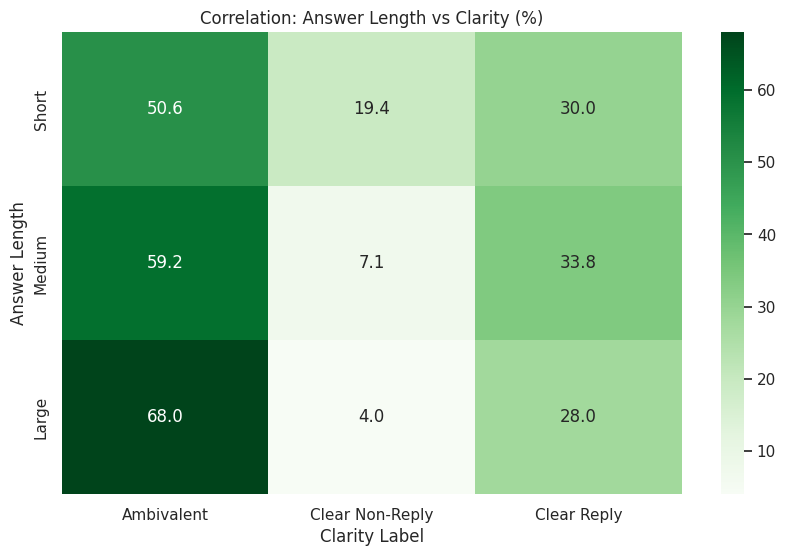

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Row-normalized crosstab
length_clarity_ct = pd.crosstab(df_all['length_category'], df_all['clarity_label'], normalize='index') * 100

sns.heatmap(length_clarity_ct, annot=True, fmt='.1f', cmap='Greens')

plt.title('Correlation: Answer Length vs Clarity (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Answer Length')

plt.show()

## Dataset Rebalancing (Smart Resampling)

This section applies a smart resampling strategy to rebalance the training dataset. The process combines semantic downsampling and paraphrase-based upsampling while preserving the original test set for evaluation.

In [11]:
import pandas as pd
from collections import Counter
from datasets import Dataset, DatasetDict

# Since the resampling functions expect a DatasetDict with at least the 'train' key,
# and df_all is a Pandas DataFrame, we temporarily convert it back.
# In this case, we separate the real Train and Test splits first (as done in Cell 2).

print("Preparing data for resampling...")

# Rebuild DatasetDict using the 'split' column created in Cell 2
train_df = df_all[df_all['split'] == 'Train'].reset_index(drop=True)
test_df = df_all[df_all['split'] == 'Test'].reset_index(drop=True)

raw_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df),
    "validation": Dataset.from_pandas(test_df) # Use test set as validation if missing
})

# Import smart resampling function from your module
from src.data.resampling import smart_resampling

# Dummy label mapping (required by the function signature, internally handled by your string-based code)
dummy_label2id = {label: i for i, label in enumerate(train_df['clarity_label'].unique())}

# EXECUTION OF THE RESAMPLING PIPELINE ON THE 3-CLASS SET ('clarity_label')
print("\nStarting Smart Resampling (Semantic Downsampling + Paraphrase Upsampling)...")

# Temporarily modify LABEL_COLUMN inside the module if required,
# or pass 'clarity_label' if supported by your updated function.
import src.data.resampling as res_module
res_module.LABEL_COLUMN = "clarity_label"

# Execute "soft" balancing
balanced_dict = smart_resampling(
    ds=raw_dict,
    label2id=dummy_label2id,
    strategy="soft",      # Uses maximum threshold logic (e.g., reduces the largest class)
    down_ratio=0.60,      # Brings the largest class down to 60% of its original size
    embed_column="interview_answer",
    paraphrase_column="interview_answer",
    seed=42
)

# Convert balanced data back to Pandas for the following heatmap analyses
df_train_balanced = balanced_dict['train'].to_pandas()
df_train_balanced['split'] = 'Train'

# Merge again with the untouched Test set
df_final_balanced = pd.concat([df_train_balanced, test_df]).reset_index(drop=True)

print("\n--- Class Distribution on Balanced Train Set ---")
print(df_final_balanced[df_final_balanced['split'] == 'Train']['clarity_label'].value_counts())

Preparing data for resampling...

Starting Smart Resampling (Semantic Downsampling + Paraphrase Upsampling)...

[smart_resampling] Strategy: 'soft'
[smart_resampling] Target distribution:
  Clear Non-Reply: 288 → 576
  Ambivalent: 1611 → 966
  Clear Reply: 859 → 966

[semantic_downsampling] Initializing 'all-MiniLM-L6-v2' ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  Paraphrasing 'Clear Non-Reply':   0%|          | 0/24 [00:00<?, ?it/s]

Flattening the indices:   0%|          | 0/859 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/966 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/288 [00:00<?, ? examples/s]


[paraphrase_upsampling] Train size: 2113 → 2508
[paraphrase_upsampling] Final distribution:
  Ambivalent                    :  966 +    0 synthetic =  966
  Clear Non-Reply               :  288 +  288 synthetic =  576
  Clear Reply                   :  859 +  107 synthetic =  966

--- Class Distribution on Balanced Train Set ---
clarity_label
Ambivalent         966
Clear Reply        966
Clear Non-Reply    576
Name: count, dtype: int64


## Feature Engineering and Behavioral Analysis on the Balanced Dataset

This section applies additional feature engineering techniques to the balanced dataset in order to extract higher-level behavioral and linguistic features from the interview answers. The analysis includes response length categorization, rhetorical tone classification, and emotion recognition.

In [12]:
import pandas as pd
import numpy as np

# Use pd.qcut to divide into 3 groups with the same number of samples (tertiles)
# labels=["Short", "Medium", "Large"]
df_final_balanced['length_category'] = pd.qcut(
    df_final_balanced['word_count_answer'],
    3,
    labels=["Short", "Medium", "Large"]
)

# Display the word ranges for each category
bins = pd.qcut(df_final_balanced['word_count_answer'], 3, retbins=True)[1]

print(f"Short range: {bins[0]:.0f} - {bins[1]:.0f} words")
print(f"Medium range: {bins[1]:.0f} - {bins[2]:.0f} words")
print(f"Large range: {bins[2]:.0f} - {bins[3]:.0f} words")

Short range: 1 - 75 words
Medium range: 75 - 297 words
Large range: 297 - 2117 words


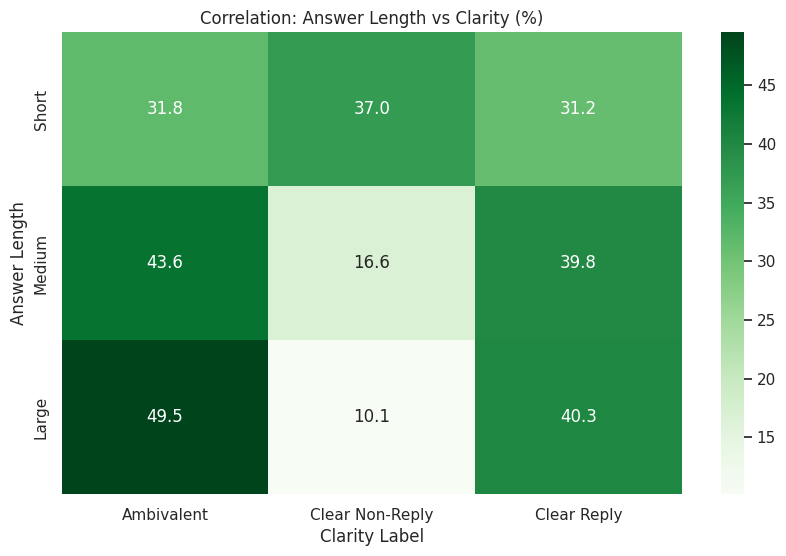

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Row-normalized crosstab
length_clarity_ct = pd.crosstab(
    df_final_balanced['length_category'],
    df_final_balanced['clarity_label'],
    normalize='index'
) * 100

sns.heatmap(length_clarity_ct, annot=True, fmt='.1f', cmap='Greens')

plt.title('Correlation: Answer Length vs Clarity (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Answer Length')

plt.show()

In [14]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Model initialization with FP16 (required for speed optimization on T4 GPUs)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0,
                      torch_dtype=torch.float16)

candidate_labels = ["Assertive", "Guarded", "Dismissive"]

# 2. Convert the column into a Hugging Face Dataset object
# Limit to 200 words to prevent GPU overload
print("Preparing data...")
temp_df = pd.DataFrame({
    "text": df_final_balanced['interview_answer'].fillna("Unknown").apply(
        lambda x: " ".join(str(x).split()[:200])
    )
})
dataset = Dataset.from_pandas(temp_df)

# 3. Execution using Dataset + Pipeline + tqdm
results = []
batch_size = 16

print(f"Starting batch analysis of {len(dataset)} rows...")

for out in tqdm(classifier(KeyDataset(dataset, "text"),
                           candidate_labels=candidate_labels,
                           batch_size=batch_size,
                           truncation=True),
                total=len(dataset)):
    results.append(out['labels'][0])

# 4. Final assignment
df_final_balanced['tone'] = results
print("Analysis completed!")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Preparing data...
Starting batch analysis of 2816 rows...


  0%|          | 0/2816 [00:00<?, ?it/s]

Analysis completed!


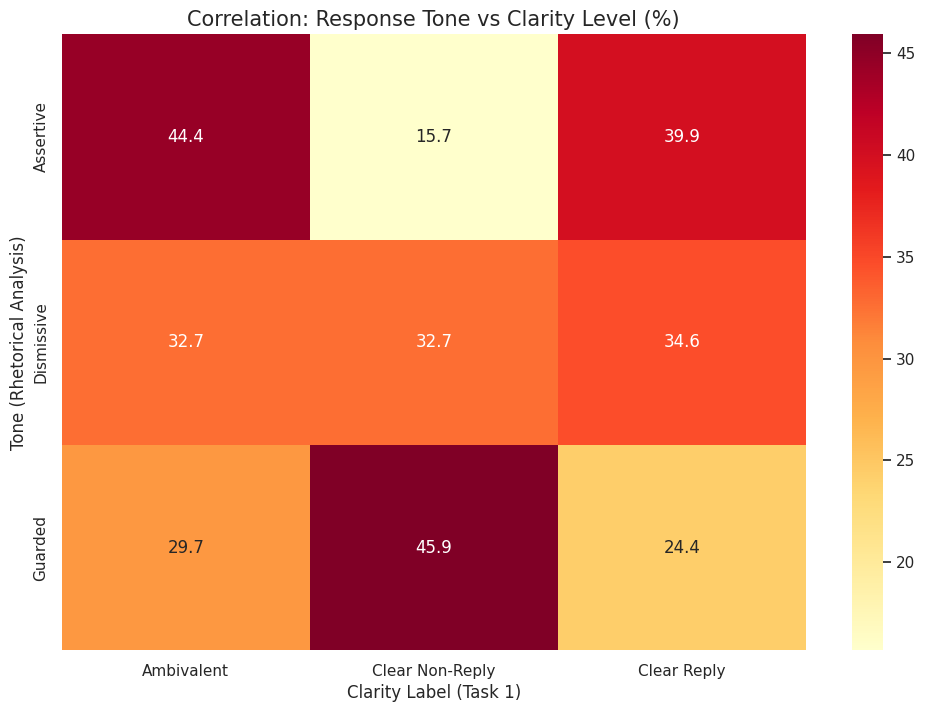

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the contingency table (Crosstab)
tone_clarity_crosstab = pd.crosstab(
    df_final_balanced['tone'],
    df_final_balanced['clarity_label'],
    normalize='index'
) * 100

# Display the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tone_clarity_crosstab, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Correlation: Response Tone vs Clarity Level (%)', fontsize=15)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Tone (Rhetorical Analysis)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/balanced_heatmap_tone_clarity_4.png", bbox_inches='tight')
plt.show()

In [16]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Emotion model initialization (Fast and accurate)
emotion_classifier = pipeline("text-classification",
                              model="j-hartmann/emotion-english-distilroberta-base",
                              device=0 if torch.cuda.is_available() else -1,
                              top_k=1) # Only keep the main predicted emotion

# 2. Prepare the Dataset (Limit to 100 words for consistency and speed)
print("Preparing data for Emotion Recognition...")
temp_df_emotion = pd.DataFrame({
    "text": df_final_balanced['interview_answer'].fillna("Unknown").apply(
        lambda x: " ".join(str(x).split()[:100])
    )
})
dataset_emotion = Dataset.from_pandas(temp_df_emotion)

# 3. Batch execution
emotion_results = []
batch_size = 16

print(f"Starting emotion analysis on {len(dataset_emotion)} rows...")

for out in tqdm(emotion_classifier(KeyDataset(dataset_emotion, "text"),
                                   batch_size=batch_size,
                                   truncation=True),
                total=len(dataset_emotion)):
    # out is a list of lists because top_k=1 is used
    emotion_results.append(out[0]['label'])

df_final_balanced['emotion'] = emotion_results
print("Emotion analysis completed!")

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Preparing data for Emotion Recognition...
Starting emotion analysis on 2816 rows...


  0%|          | 0/2816 [00:00<?, ?it/s]

Emotion analysis completed!


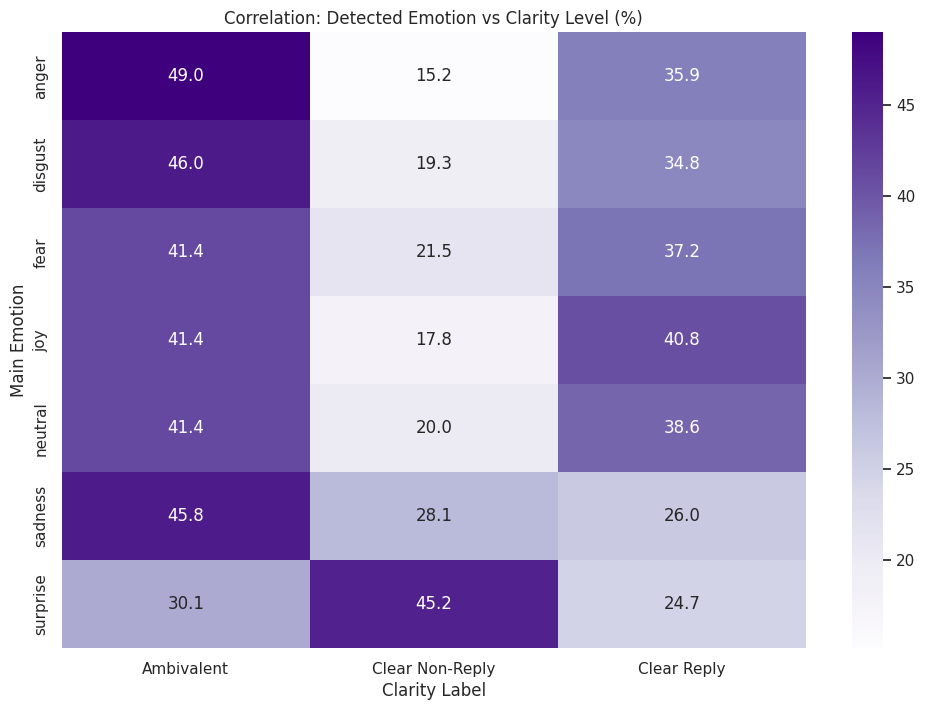

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Crosstab between emotions and clarity labels
emotion_ct = pd.crosstab(
    df_final_balanced['emotion'],
    df_final_balanced['clarity_label'],
    normalize='index'
) * 100

sns.heatmap(emotion_ct, annot=True, fmt='.1f', cmap='Purples')

plt.title('Correlation: Detected Emotion vs Clarity Level (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Main Emotion')

plt.show()